In [5]:
import numpy as np
import orbitengine.engine as oe
import astropy.units as u
import scipy.constants
from poliastro.bodies import Earth
from poliastro.twobody import Orbit
from scipy.optimize import minimize
import orbitengine.trajectorysegment as ts
from orbitengine.body import Body
import time
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
from poliastro import iod
import json


# def transfer_dv(x, state0, state0_target, k, t_wieght=0.0001):
#     t, tof = x
#     t *= u.s
#     tof *= u.s
#     state1 = state0.propagate_cowell(k, t)

#     target1 = state0_target.propagate_cowell(k, t+tof)
#     res = list(iod.izzo.lambert(Earth.k, state1.position, target1.position, tof, M=0))
#     if len(res) == 0 or len(res) > 1:
#         print(f"lambert produced {len(res)} solutions")
#     v0_sol, v1_sol = res[0]
#     dv1 = np.linalg.norm(v0_sol - state1.velocity).value
#     dv2 = np.linalg.norm(v1_sol - target1.velocity).value
#     dt = (t+tof).value*t_wieght

#     return dv1*dv1+dv2*dv2+dt*dt


def transfer_launch_dv(x, state0, state0_target, k, parent_axis_angle=None, t_wieght=0.0001):
    t_delay, t_flight = x
    t_delay *= u.s
    t_flight *= u.s

    if parent_axis_angle is None:
        state_pre_transfer = state0.propagate_cowell(k, t_delay)
    else:
        state_pre_transfer = state0.propagate_landed(t_delay, parent_axis_angle)

    target_post_transfer = state0_target.propagate_cowell(k, t_delay+t_flight)
    res = list(iod.izzo.lambert(Earth.k, state_pre_transfer.position, target_post_transfer.position, t_flight, M=0))
    if len(res) == 0 or len(res) > 1:
        print(f"lambert produced {len(res)} solutions")
    v0_sol, v1_sol = res[0]

    ground_penalty = 0

    #add cost for not being aligned with the surface normal
    if parent_axis_angle is not None:
        ndot = np.dot(v0_sol/np.linalg.norm(v0_sol), state_pre_transfer.position/np.linalg.norm(state_pre_transfer.position))
        # must point slightly upwards from the surface
        if ndot < 0.1:
            ground_penalty = 10000  # arbitrary large number, is this sufficient?
        
    dv1 = np.linalg.norm(v0_sol - state_pre_transfer.velocity).value
    dv2 = np.linalg.norm(v1_sol - target_post_transfer.velocity).value
    dt = (t_delay+t_flight).value*t_wieght

    return dv1*dv1+dv2*dv2+dt*dt + ground_penalty


k = Earth.k.to(u.km**3/u.s**2)
parent_axis_angle = [0,0,2*np.pi/(24*3600)]*u.rad/u.s



[5110.82083536  687.94423652] 51.35663045062966
saved to transfer_solution.json


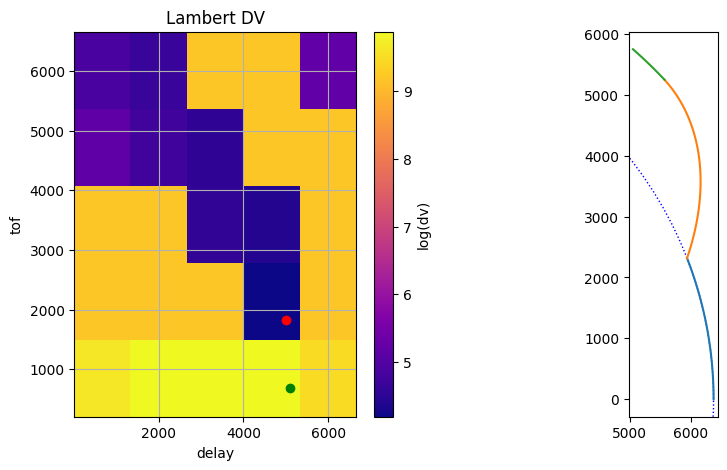

In [12]:


# rocket on ground
r0 = np.array([oe.EARTH_RADIUS_KM.value, 0, 0])*u.km
v0 = np.array([0, 7.90538864 , 0])*u.km/u.s  # near circular orbit
# res = minimize(oe.eccentricity, v0.value, args=(r0.value, k.value))
# print(res.x)
ground_velocity = oe.EARTH_RADIUS_KM*2*np.pi/(24*3600*u.s)

m0 = 350*u.kg # rocket + fuel
T0 = oe.TEMP_EARTH
isp = oe.SPECIFIC_IMPULSE_TYPE.Liquid
flow = oe.REACTION_MASS_FLOW_RATE
state_init = Body.State( r0, v0, m0, T0,0*u.s)
per_source = state_init.period(k)

# compute a target in circular orbit
r_target = np.array([0,1.2*oe.EARTH_RADIUS_KM.value,  0])*u.km
v_target = np.array([-5.59,0 , 0])*u.km/u.s
res = minimize(oe.eccentricity, v_target.value, args=(r_target.value, k.value))
v_target = res.x*u.km/u.s
state_target = Body.State(r_target, v_target)
per_target = state_target.period(k)

max_time = 10000*u.s
if not np.isnan(per_source) and not np.isnan(per_target):
    if per_source > per_target:
        max_time = per_source
    else:
        max_time = per_target

#use priods to define search bounds
travel_max = max_time.value
delay_max = max_time.value
time_weight = 0.0005

# grid search lambert solutions to find minimum total dv
resolution = 5
travel_times = np.linspace(200, travel_max, resolution)*u.s
delay_times = np.linspace(10, delay_max, resolution)*u.s
dv = np.zeros((len(delay_times), len(travel_times)))

for delay_idx in range(len(delay_times)):
    for tof_idx in range(len(travel_times)):
        try:
            res = transfer_launch_dv([delay_times[delay_idx].value, 
                          travel_times[tof_idx].value], 
                          state_init, state_target, 
                          k, 
                          parent_axis_angle,
                          t_wieght=time_weight)
            dv[tof_idx,delay_idx] = np.log(res)
        except Exception as e:
            dv[tof_idx,delay_idx] = 9 # big number to avoid nan, can we do better?


fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot dv grid as image --------------------------
axs[0].imshow(dv, cmap='plasma', origin='lower', extent=[delay_times.min().value, delay_times.max().value,travel_times.min().value, travel_times.max().value])

# show color scale
cbar = plt.colorbar(axs[0].imshow(dv, cmap='plasma', origin='lower', extent=[delay_times.min().value, delay_times.max().value,travel_times.min().value, travel_times.max().value]))
cbar.set_label('log(dv)')

axs[0].set_ylabel('tof')
axs[0].set_xlabel('delay')
axs[0].set_title('Lambert DV')
axs[0].grid(True)
axs[0].set_aspect('auto', adjustable='box')


#init guess based on sampling
min_indices = np.unravel_index(np.argmin(dv), dv.shape)
t_delay_min_dv = delay_times[min_indices[1]]
t_flight_min_dv = travel_times[min_indices[0]]
# plot the minimum dv
axs[0].plot(t_delay_min_dv, t_flight_min_dv,  'ro')

# optimize minimum dv from initial guess
x0 = [t_delay_min_dv.value,t_flight_min_dv.value]
bounds = [[0, delay_max], [1, travel_max]]
res = minimize(transfer_launch_dv, x0, args=(state_init, state_target, k, parent_axis_angle, time_weight), bounds=bounds)
t_delay_min_dv = res.x[0]*u.s
t_flight_min_dv = res.x[1]*u.s
axs[0].plot(t_delay_min_dv, t_flight_min_dv,  'go')
print(res.x, res.fun)

# plot transfer trajectory --------------------------
state_pre_transfer = state_init.propagate_landed(t_delay_min_dv, parent_axis_angle)
res = list(iod.izzo.lambert(Earth.k, state_pre_transfer.position, state_target.propagate_cowell(k, t_delay_min_dv+t_flight_min_dv).position, t_flight_min_dv, M=0))
v1_sol = res[0][0]
r1_sol = state_pre_transfer.position
state_transfer = Body.State(r1_sol, v1_sol, m0, T0, t_delay_min_dv)

transfer_sol_filename = 'transfer_solution.json'
with open(transfer_sol_filename, 'w') as f:
    transfer_solution = {
        "t_delay": t_delay_min_dv.value,
        "t_flight": t_flight_min_dv.value,
        "state_init": state_init.to_dict(),
        "state_target": state_target.to_dict(),
        "state_transfer": state_transfer.to_dict()
    }
    json.dump(transfer_solution, f, indent=2)
    print(f"saved to {transfer_sol_filename}")


positions_init = []
positions_transfer = []
positions_target = []

for t in np.linspace(0, t_delay_min_dv, 100):
    if parent_axis_angle is None:
        positions_init.append(state_init.propagate_cowell(k,t).position)
    else:
        positions_init.append(state_init.propagate_landed(t, parent_axis_angle).position)
axs[1].plot([p[0].value for p in positions_init], [p[1].value for p in positions_init], label='Landed')

for t in np.linspace(0, t_flight_min_dv, 100):
    positions_transfer.append(state_transfer.propagate_cowell(k,t).position)
axs[1].plot([p[0].value for p in positions_transfer], [p[1].value for p in positions_transfer], label='Transfer')

for t in np.linspace(0, 100*u.s, 100):
    positions_target.append(state_target.propagate_cowell(k,t_delay_min_dv + t_flight_min_dv + t).position)
axs[1].plot([p[0].value for p in positions_target], [p[1].value for p in positions_target], label='Target')

circle = plt.Circle((0, 0), oe.EARTH_RADIUS_KM.value, color='b', fill=False, linestyle='dotted')
axs[1].add_artist(circle)
axs[1].set_aspect('equal', adjustable='box')



plt.show()

C:\Users\jcl5m\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ode.py:1348: UserWarning: lsoda: Excess work done on this call (perhaps wrong Dfun type).
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


Optimized Maneuver Err: 9.5027961400797e-12
Post Maneuver Mass: 231.57674650260464 kg


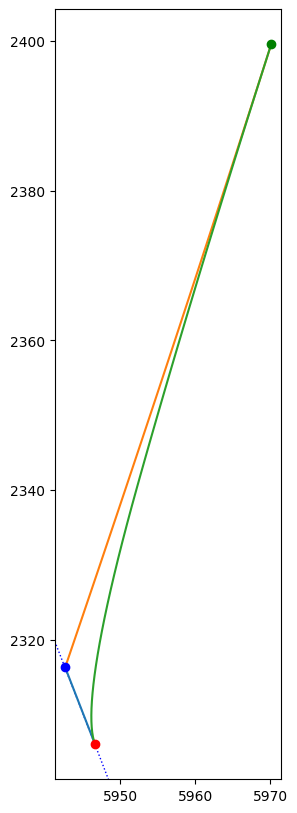

C:\Users\jcl5m\AppData\Local\Temp\ipykernel_8876\4198631856.py:126: RuntimeWarning: invalid value encountered in scalar divide
  a = np.linalg.norm(s2.velocity-s1.velocity).value/(s2.timestamp - s1.timestamp).value


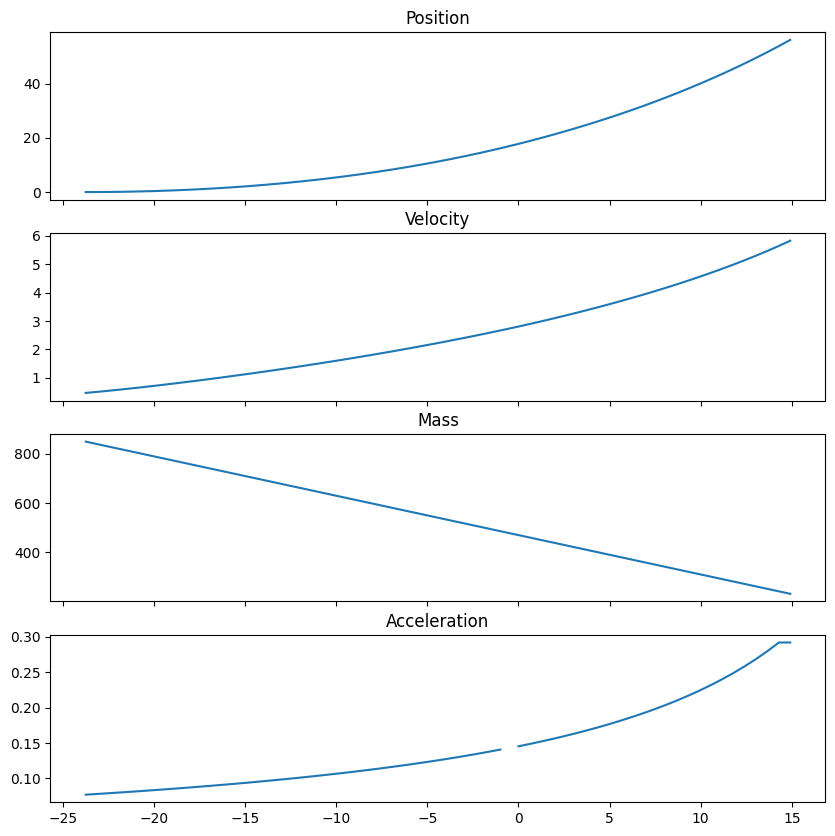

Optimized Maneuver Err: 4.1120335896520516e-14
Post Maneuver Mass: 106.1400227067876 kg


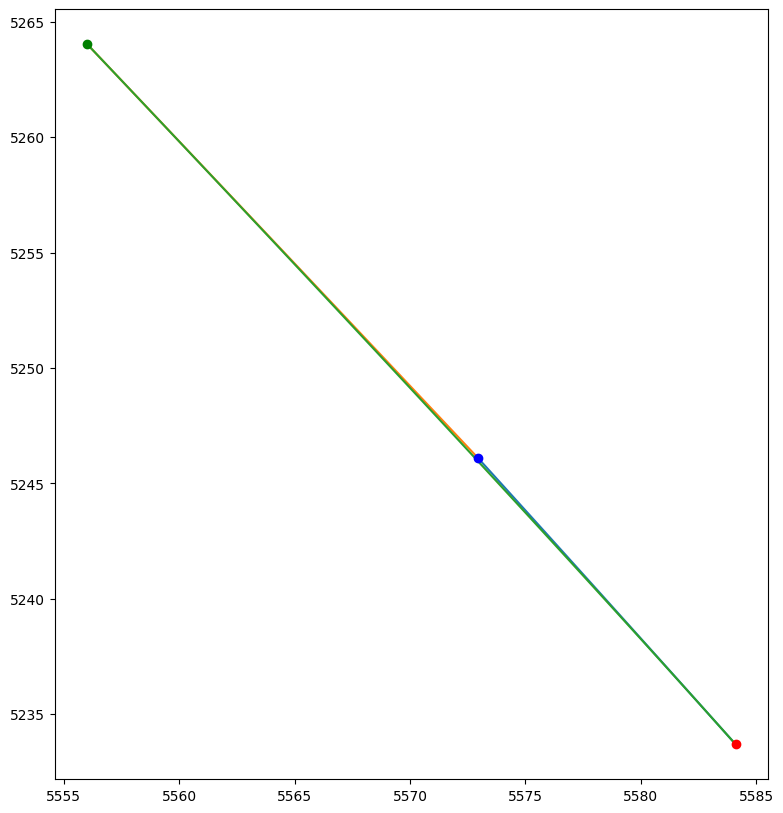

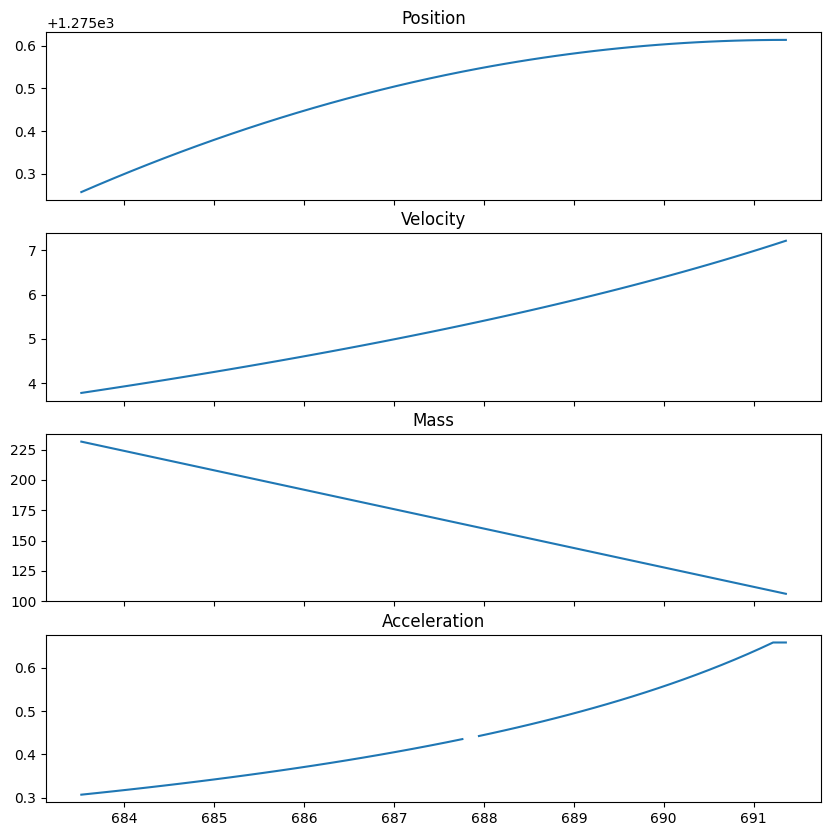

In [23]:
import math
import pickle


with open(transfer_sol_filename, 'r') as f:
    transfer_solution = json.load(f)
    state_landed = Body.State.from_dict(transfer_solution["state_init"])
    state_transfer = Body.State.from_dict(transfer_solution["state_transfer"])
    state_target = Body.State.from_dict(transfer_solution["state_target"])

    t_delay = transfer_solution["t_delay"]*u.s
    t_flight = transfer_solution["t_flight"]*u.s


# set fuel mas and flow rate
flow_rate = 20*oe.REACTION_MASS_FLOW_RATE
wet_mass = 850*u.kg
isp = oe.SPECIFIC_IMPULSE_TYPE.Liquid
state_landed.mass = wet_mass
state_transfer.mass = wet_mass
state_target.mass = wet_mass
dry_mass =  oe.ROCKET_DRY_MASS

# init guess
class ThrustManeuver:
    def __init__(self, state_init, state_target, k, t_maneuver, flow_rate, isp, dry_mass, parent_axis_angle=None):
        self.state_init = state_init  # state prior to the maneuver along which t_manuever if propagated
        self.state_target = state_target # target state post maneuver calculated from t_maneuver forward
        self.k = k # gravitational parameter
        self.t_maneuver = t_maneuver # time of the instaneous maneuver
        self.flow_rate = flow_rate # mass flow rate
        self.isp = isp # specific impulse
        self.parent_axis_angle = parent_axis_angle # if None, not landed otherwise use to propogate state_start
        self.state_post_maneuver = None
        self.mass_dry = dry_mass

    def maneuver_err(self, x):
        t_init_burn = x[0]*u.s
        t_correction_burn = x[1]*u.s
        thrust_vec_init = R.from_rotvec([0,0,x[2]]).apply(oe.ZERO_ANGLE_VECTOR)
        thrust_vec_correction = R.from_rotvec([0,0,x[3]]).apply(oe.ZERO_ANGLE_VECTOR)

        acc_param_init = oe.AccParams(thrust_vec=thrust_vec_init,
                                reaction_flow_rate=self.flow_rate,
                                reaction_isp=self.isp,
                                mass_dry=self.mass_dry)
        acc_param_correction = oe.AccParams(thrust_vec=thrust_vec_correction,
                                reaction_flow_rate=self.flow_rate,
                                reaction_isp=self.isp,
                                mass_dry=self.mass_dry)
        if self.parent_axis_angle is None:
            s0 = self.state_init.propagate_cowell(self.k, self.t_maneuver - t_init_burn)
        else:
            s0 = self.state_init.propagate_landed(self.t_maneuver - t_init_burn, self.parent_axis_angle)
        s1a = s0.propagate_cowell(self.k, t_init_burn, acc_params=acc_param_init)
        s1 = s1a.propagate_cowell(self.k, t_correction_burn, acc_params=acc_param_correction)

        self.state_post_maneuver = s1
        s2 = self.state_target.propagate_cowell(self.k, t_correction_burn)
        dr = np.linalg.norm(s1.position - s2.position).value
        dv = np.linalg.norm(s1.velocity - s2.velocity).value
        return dr*dr + dv*dv

    def __str__(self):
        return str(self.__dict__)

    def optimize(self):
        if self.parent_axis_angle is None:
            state_intercept = self.state_init.propagate_cowell(self.k, self.t_maneuver)
        else:
            state_intercept = self.state_init.propagate_landed(self.t_maneuver, self.parent_axis_angle)

        #initial guess
        maneuver_dv = np.linalg.norm(self.state_target.velocity - state_intercept.velocity)
        acc = oe.EARTH_G0*self.isp * self.flow_rate/self.state_init.mass
        t_init_burn = 0.25*maneuver_dv/acc  # 0.5 seemed to put it in a local minimum
        t_correction_burn = 1*t_init_burn
        maneuver_angle = math.atan2(self.state_target.velocity[1].value, self.state_target.velocity[0].value)
        launch_thrust_angle = maneuver_angle
        correction_thrust_angle = maneuver_angle

        x = [t_init_burn.value, t_correction_burn.value, launch_thrust_angle,correction_thrust_angle]
        res = minimize(self.maneuver_err, x) 
        self.t_init_burn = res.x[0]*u.s
        self.t_correction_burn = res.x[1]*u.s
        self.launch_thrust_angle = res.x[2]
        self.correction_thrust_angle = res.x[3]
        return res.fun
    
    def states(self, count=50):
        # rocket trajectory
        states_maneuver = []
        thrust_vec_init = R.from_rotvec([0,0,self.launch_thrust_angle]).apply(oe.ZERO_ANGLE_VECTOR)
        thrust_vec_correction = R.from_rotvec([0,0,self.correction_thrust_angle]).apply(oe.ZERO_ANGLE_VECTOR)
        acc_param_init_burn = oe.AccParams(thrust_vec=thrust_vec_init,
                                    reaction_flow_rate=flow_rate,
                                    reaction_isp=isp)
        acc_param_correction_burn = oe.AccParams(thrust_vec=thrust_vec_correction,
                                    reaction_flow_rate=flow_rate,
                                    reaction_isp=isp)

        if self.parent_axis_angle is None:
            state_init_burn = self.state_init.propagate_cowell(self.k, self.t_maneuver - self.t_init_burn)
        else:
            state_init_burn = self.state_init.propagate_landed(self.t_maneuver - self.t_init_burn, self.parent_axis_angle)

        # rocket trajectory
        for t in np.linspace(0, self.t_init_burn, int(count/2)):
            s = state_init_burn.propagate_cowell(self.k,t, acc_params=acc_param_init_burn)
            states_maneuver.append(s)
        state_correction_burn = states_maneuver[-1]
        for t in np.linspace(0, self.t_correction_burn, int(count/2)):
            s = state_correction_burn.propagate_cowell(self.k,t, acc_params=acc_param_correction_burn)
            states_maneuver.append(s)  

        return states_maneuver

    def plot_components(self):
        # plot components of the flight
        fig, axs = plt.subplots(nrows=4, sharex=True, figsize=(10,10))
        states_maneuver = self.states()
        accel = []
        for i in range(len(states_maneuver)-1):
            s1 = states_maneuver[i]
            s2 = states_maneuver[i+1]
            a = np.linalg.norm(s2.velocity-s1.velocity).value/(s2.timestamp - s1.timestamp).value
            accel.append(a)
        accel.append(accel[-1]) # pad to be equal length

        times = [s.timestamp.value for s in states_maneuver]-t_delay.value
        axs[0].plot(times, [np.linalg.norm(s.position).value - oe.EARTH_RADIUS_KM.value for s in states_maneuver])
        axs[0].title.set_text('Position')
        axs[1].plot(times, [np.linalg.norm(s.velocity).value for s in states_maneuver])
        axs[1].title.set_text('Velocity')
        axs[2].plot(times, [s.mass.value for s in states_maneuver])
        axs[2].title.set_text('Mass')
        axs[3].plot(times, accel)
        axs[3].title.set_text('Acceleration')
        plt.show()

    def plot(self):
        # compute and plot body trajectories
        positions_init = []
        positions_target = []

        states_maneuver = self.states()

        if self.parent_axis_angle is None:
            # init trajectory
            for t in np.linspace(self.t_maneuver-self.t_init_burn, self.t_maneuver, 50):
                s = self.state_init.propagate_cowell(self.k,t)
                positions_init.append(s.position)
        else:
            # init trajectory
            for t in np.linspace(self.t_maneuver-self.t_init_burn, self.t_maneuver, 50):
                s = self.state_init.propagate_landed(t, self.parent_axis_angle)
                positions_init.append(s.position)

        #target trajectory
        for t in np.linspace(0, self.t_correction_burn, 50):
            s = self.state_target.propagate_cowell(self.k, t)
            positions_target.append(s.position)

        fig, axs = plt.subplots(1, 1, figsize=(10, 10))
        axs.plot([p[0].value for p in positions_init], [p[1].value for p in positions_init], label='Init')
        axs.plot([p[0].value for p in positions_target], [p[1].value for p in positions_target], label='Target')
        axs.plot([s.position[0].value for s in states_maneuver], [s.position[1].value for s in states_maneuver], label='Maneuver')

        p = states_maneuver[0].position
        axs.plot(p[0], p[1], 'ro')

        p = self.state_target.position
        axs.plot(p[0], p[1], 'bo')

        p = self.state_post_maneuver.position
        axs.plot(p[0], p[1], 'go')

        circle = plt.Circle((0, 0), oe.EARTH_RADIUS_KM.value, color='b', fill=False, linestyle='dotted')
        axs.add_artist(circle)
        axs.set_aspect('equal', adjustable='box')

        plt.show()

m1 = ThrustManeuver(state_landed, state_transfer, k, t_delay, flow_rate, isp, dry_mass, parent_axis_angle)

print(f"Optimized Maneuver Err: {m1.optimize()}")
print(f"Post Maneuver Mass: {m1.state_post_maneuver.mass}")
with open('maneuver1.json', 'wb') as f:
    pickle.dump(m1, f)
m1.plot()
m1.plot_components()

state_target2 = state_target.propagate_cowell(k, t_delay + t_flight)
state_transfer.mass = m1.state_post_maneuver.mass
m2 = ThrustManeuver(state_transfer, state_target2, k, t_flight, flow_rate, isp, dry_mass)

print(f"Optimized Maneuver Err: {m2.optimize()}")
print(f"Post Maneuver Mass: {m2.state_post_maneuver.mass}")
with open('maneuver2.json', 'wb') as f:
    pickle.dump(m2, f)
m2.plot()
m2.plot_components()




Timestamp: 5110.820835363776 s
Position: [5942.61846988 2316.3430945     0.        ] km
Velocity: [1.91222573 5.60517073 0.        ] km / s
Mass: 850.0 kg
Tempurature: 0.0 K



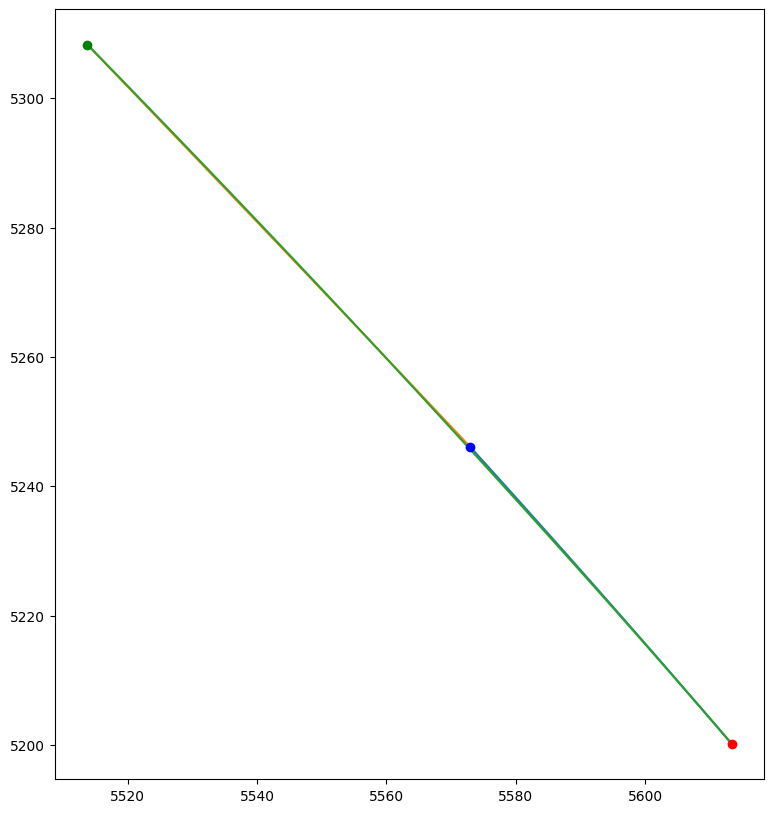

In [4]:
import pickle
# with open('maneuver1.json', 'rb') as fp:
#     m11 = pickle.load(fp)
#     print(m11)
#     m11.plot()

with open('maneuver2.json', 'rb') as fp:
    m22 = pickle.load(fp)
    print(m22.state_init)
    m22.plot()


#print(vars(m22))
